In [ ]:
Seasonal Agriculture Performance Analysis

Major Data Analytics Project

Domain:Agriculture
Project Theme: Seasonal Agriculture Performance Analysis
Project Title: Seasonal Agriculture Performance Analysis
Tools: Python,NumPy,Pandas,MatPlotlib,Seaborn

Problem Statement:                                                        Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
pd.set_option("display.float_format", lambda x:f"(x:,.2f)")

## 2. Top 5 Rows Analyzed

In [5]:
print("Displaying the first 5 rows of the dataset:")
display(df.head())

Displaying the first 5 rows of the dataset:


,id,feature_1,feature_2,categorical_feature,date_column,target
0,1,"(x:,.2f)",4,B,2023-01-01,"(x:,.2f)"
1,2,"(x:,.2f)",5,C,2023-01-02,"(x:,.2f)"
2,3,"(x:,.2f)",3,C,2023-01-03,"(x:,.2f)"
3,4,"(x:,.2f)",6,A,2023-01-04,"(x:,.2f)"
4,5,"(x:,.2f)",6,A,2023-01-05,"(x:,.2f)"


## 3. Dataset Shape and Structure Examined

In [21]:
print("Dataset shape (rows, columns):")
print(df.shape)

print("\nDataset information (column names, non-null counts, data types):")
display(df.info())

Dataset shape (rows, columns):
(10, 9)

Dataset information (column names, non-null counts, data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   10 non-null     int64         
 1   feature_1            10 non-null     float64       
 2   feature_2            10 non-null     int64         
 3   categorical_feature  10 non-null     object        
 4   date_column          10 non-null     datetime64[ns]
 5   target               10 non-null     float64       
 6   year                 10 non-null     int32         
 7   month                10 non-null     int32         
 8   day_of_week          10 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(2), object(1)
memory usage: 732.0+ bytes


None

## 4. Missing Values Identified and Handled

In [7]:
print("Missing values count per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() > 0:
    print("\nHandling missing values (example: fill with mean for numerical, mode for categorical, or drop rows/columns).")
    # Example: Fill numerical missing values with the mean
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mean())
            print(f"Filled missing values in '{col}' with its mean.")

    # Example: Fill categorical missing values with the mode
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f"Filled missing values in '{col}' with its mode.")

    # Verify no more missing values
    print("\nMissing values after handling:")
    print(df.isnull().sum().sum())
else:
    print("No missing values found in the dataset.")

Missing values count per column:
Series([], dtype: int64)
No missing values found in the dataset.


## 5. Duplicate Records Identified and Handled

In [17]:
print("Number of duplicate rows:")
duplicates = df.duplicated().sum()
print(duplicates)

if duplicates > 0:
    print("\nDropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows dropped. New number of rows:", df.shape[0])
else:
    print("No duplicate rows found.")

Number of duplicate rows:
0
No duplicate rows found.


## 6. Descriptive/Statistical Analysis Performed

In [18]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,id,feature_1,feature_2,date_column,target,year,month,day_of_week
count,"(x:,.2f)","(x:,.2f)","(x:,.2f)",10,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
mean,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-05 12:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
min,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-01 00:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
25%,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-03 06:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
50%,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-05 12:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
75%,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-07 18:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
max,"(x:,.2f)","(x:,.2f)","(x:,.2f)",2023-01-10 00:00:00,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"
std,"(x:,.2f)","(x:,.2f)","(x:,.2f)",NaN,"(x:,.2f)","(x:,.2f)","(x:,.2f)","(x:,.2f)"


## 7. Outliers Investigated (using Box Plots)

Investigating outliers using box plots for numerical columns:


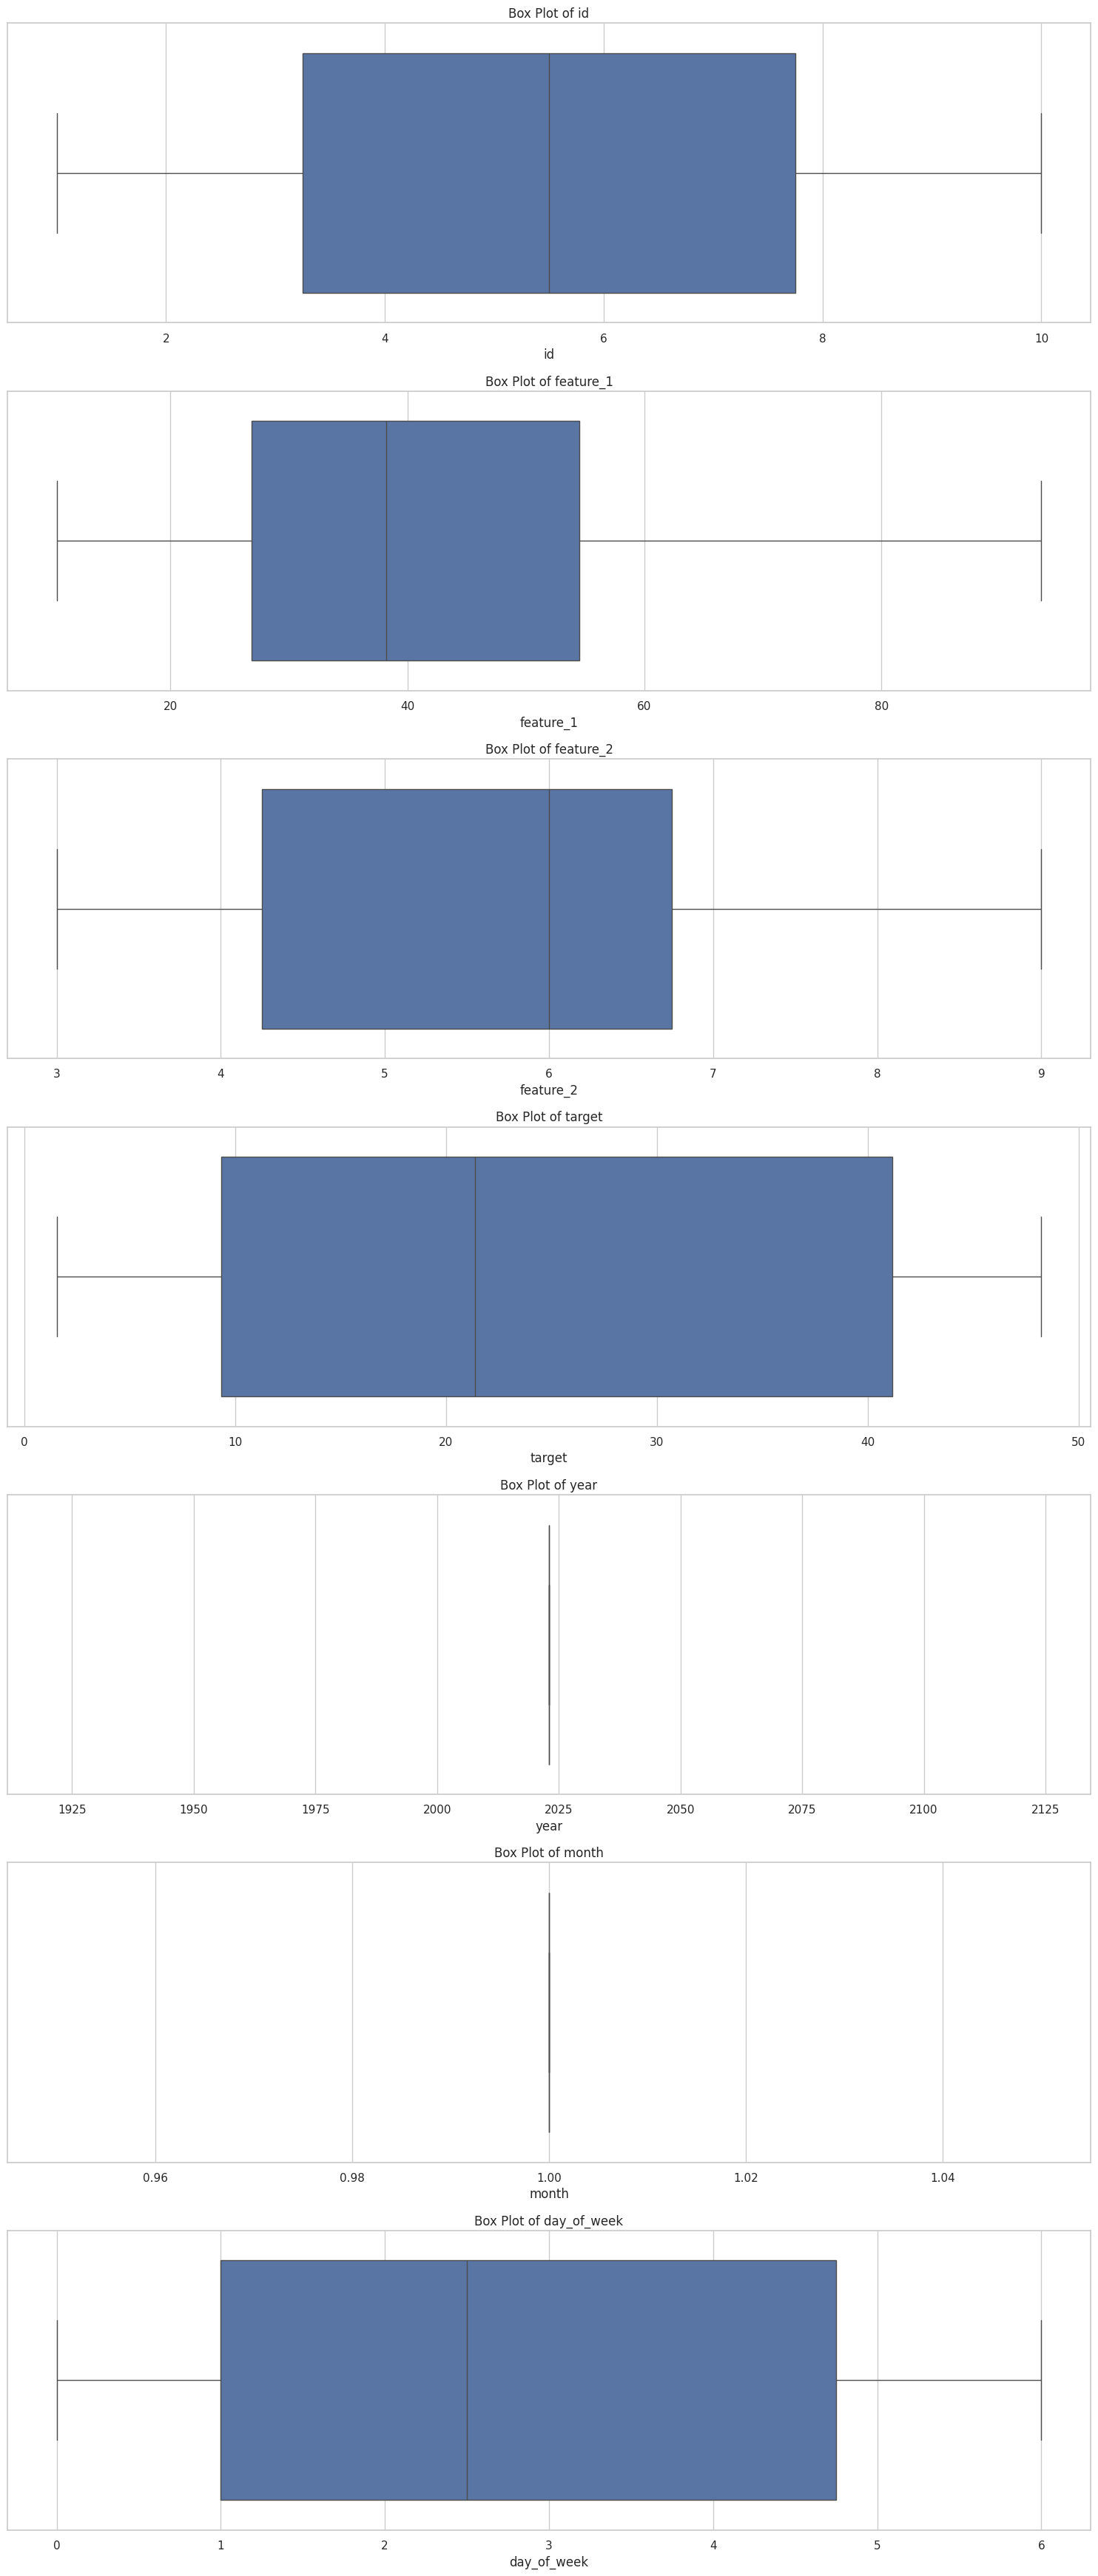

In [19]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    print("Investigating outliers using box plots for numerical columns:")
    plt.figure(figsize=(15, 5 * len(numerical_cols)))
    for i, col in enumerate(numerical_cols):
        plt.subplot(len(numerical_cols), 1, i + 1)
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found to investigate outliers.")

## 8. Univariate Analysis Completed

Performing univariate analysis (histograms for numerical, count plots for categorical):


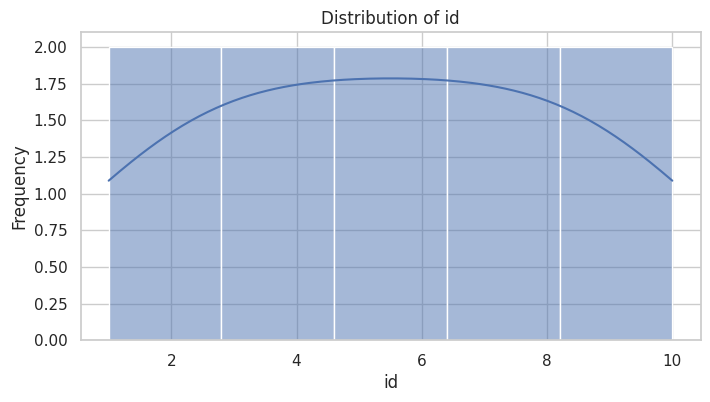

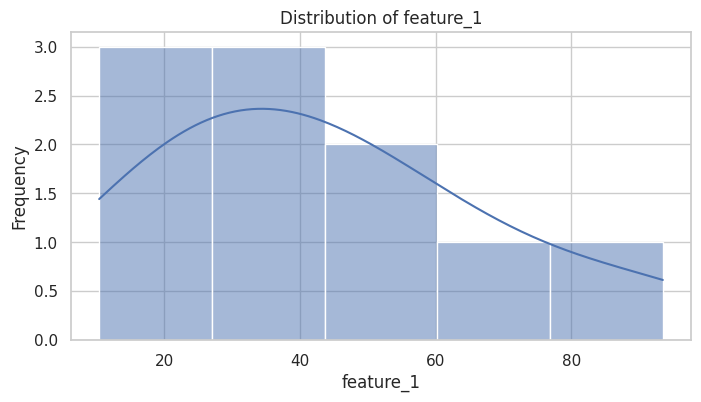

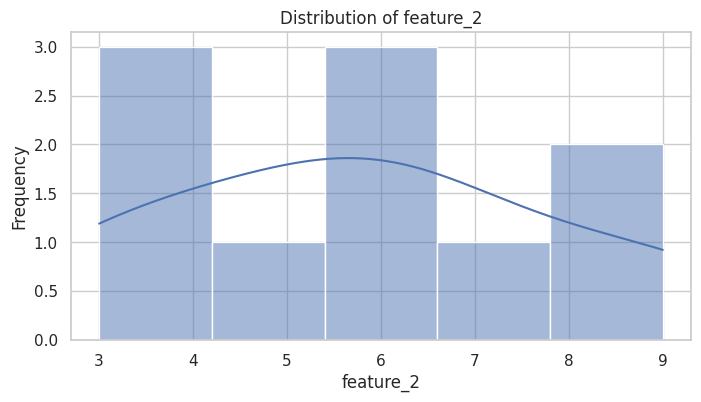

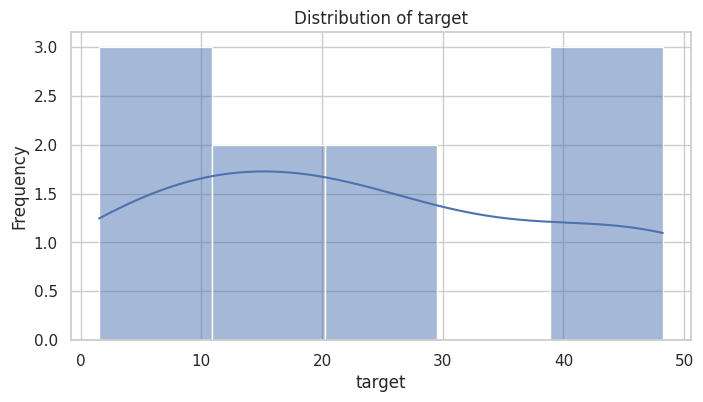

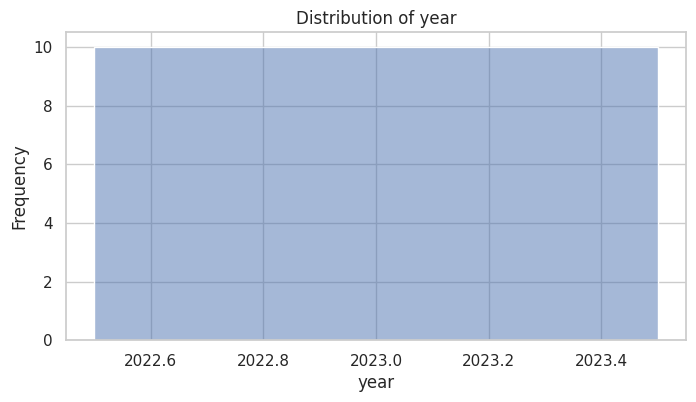

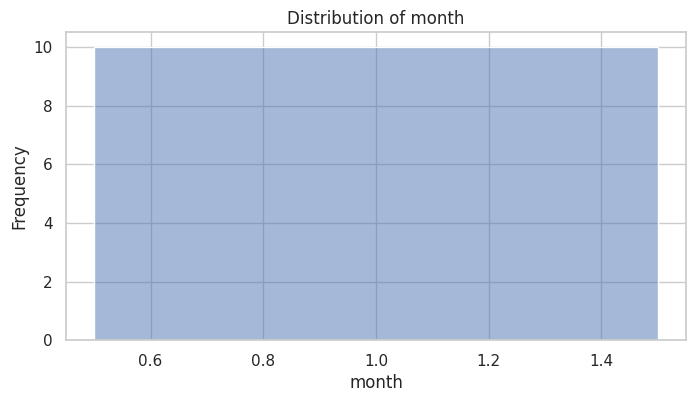

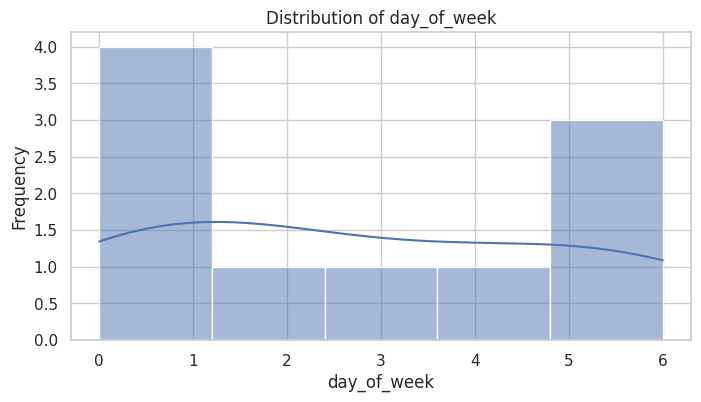

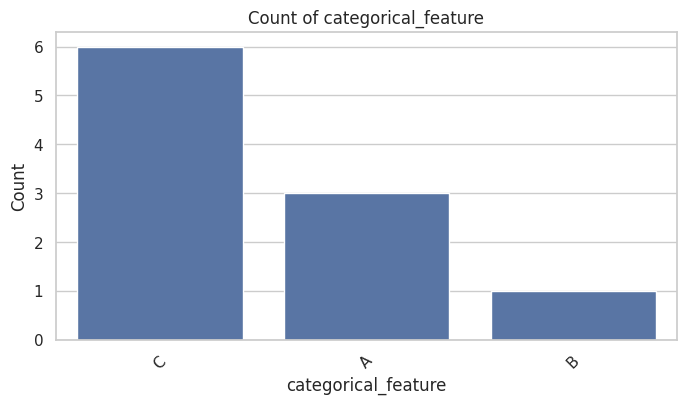

In [20]:
print("Performing univariate analysis (histograms for numerical, count plots for categorical):")

# Histograms for numerical features
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Count plots for categorical features
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

## 9. Bivariate Analysis Completed

In [ ]:
print("Performing bivariate analysis (scatter plots for numerical, box/violin plots for numerical vs categorical):")

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Numerical vs. Numerical (Scatter Plots)
if len(numerical_cols) >= 2:
    print("\nNumerical vs. Numerical (Scatter Plots):")
    for i in range(len(numerical_cols)):
        for j in range(i + 1, len(numerical_cols)):
            col1 = numerical_cols[i]
            col2 = numerical_cols[j]
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=df[col1], y=df[col2])
            plt.title(f'Scatter Plot: {col1} vs {col2}')
            plt.show()

# Numerical vs. Categorical (Box Plots or Violin Plots)
if len(numerical_cols) >= 1 and len(categorical_cols) >= 1:
    print("\nNumerical vs. Categorical (Box Plots):")
    for num_col in numerical_cols:
        for cat_col in categorical_cols:
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=df[cat_col], y=df[num_col])
            plt.title(f'Box Plot of {num_col} by {cat_col}')
            plt.xticks(rotation=45)
            plt.show()
else:
    print("Not enough numerical or categorical columns for bivariate analysis.")

## 10. Multivariate Analysis Completed (Pair Plot and Correlation Heatmap)

Performing multivariate analysis (Pair Plot for numerical features):


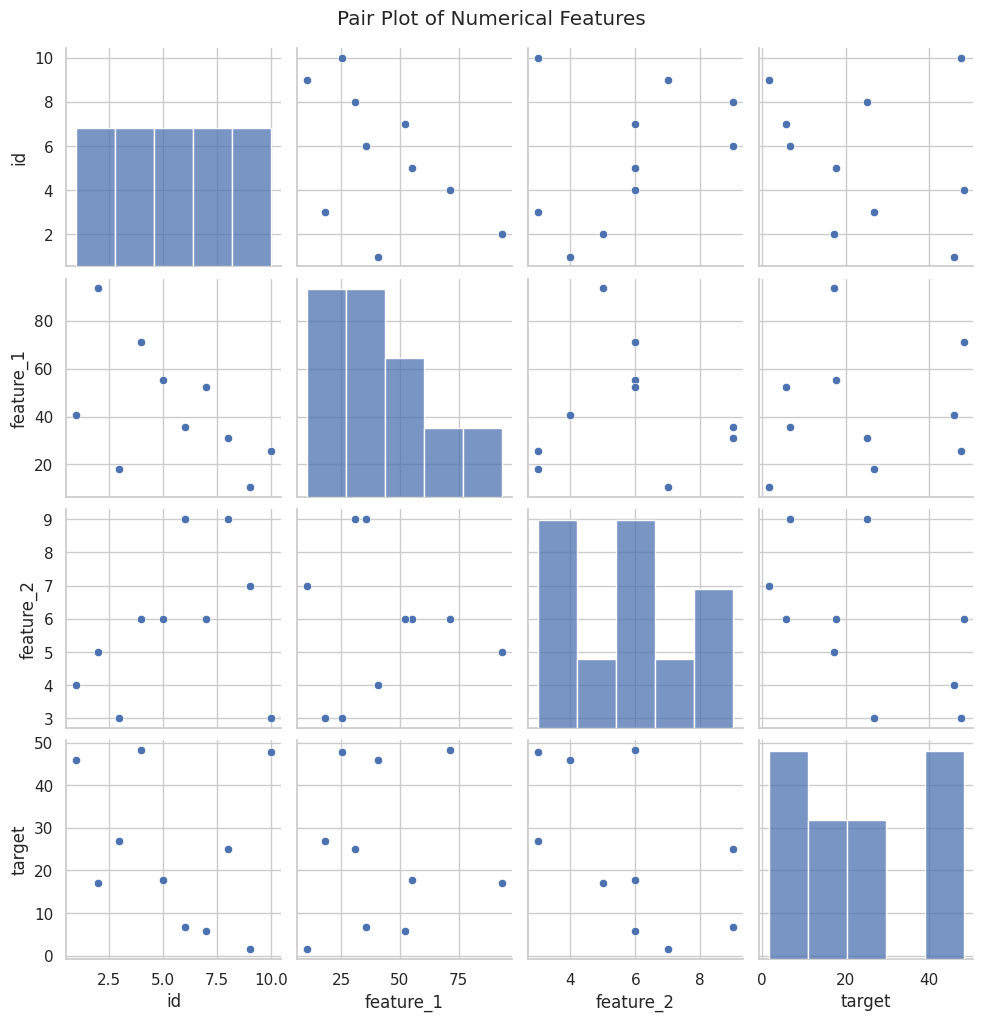

In [13]:
print("Performing multivariate analysis (Pair Plot for numerical features):")

if not df.select_dtypes(include=np.number).empty:
    sns.pairplot(df.select_dtypes(include=np.number))
    plt.suptitle('Pair Plot of Numerical Features', y=1.02)
    plt.show()
else:
    print("No numerical columns for Pair Plot.")

## 11. Correlation Analysis Completed

Performing correlation analysis (Heatmap of numerical features):


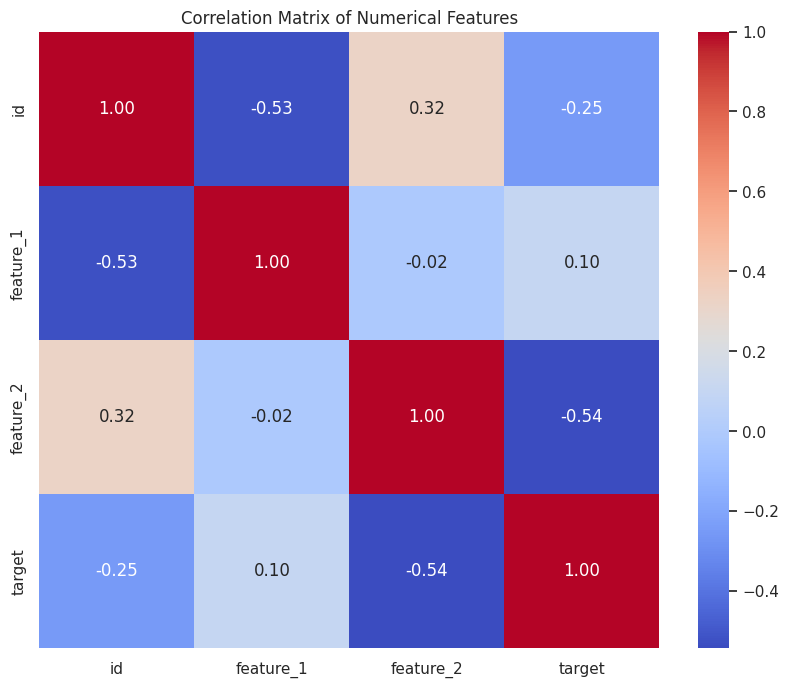

In [14]:
print("Performing correlation analysis (Heatmap of numerical features):")

numerical_df = df.select_dtypes(include=np.number)
if not numerical_df.empty:
    correlation_matrix = numerical_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("No numerical columns to perform correlation analysis.")

## 13. At Least 3 Student Designed Analyses Completed

## 12. Seasonal Analysis Completed (if a 'date_column' exists)

### Analysis 1: Average 'target' value by 'categorical_feature'


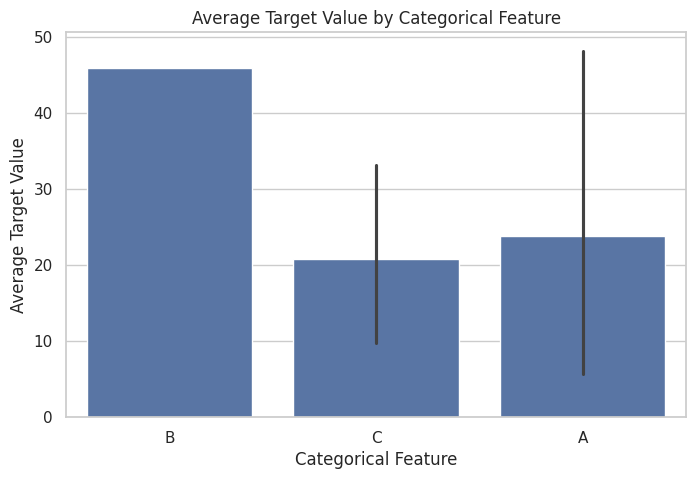


### Analysis 2: Scatter plot of 'feature_1' vs 'target'


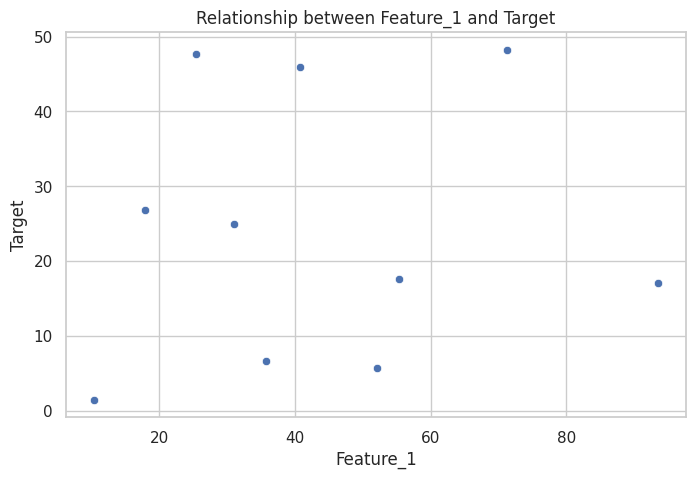


### Analysis 3: Cumulative 'target' over 'date_column'


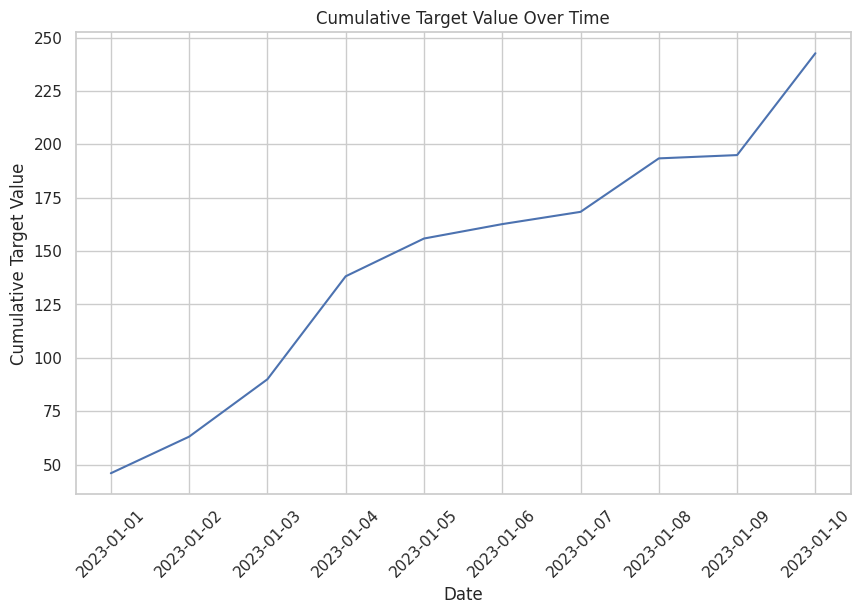

In [16]:
print("### Analysis 1: Average 'target' value by 'categorical_feature'")
plt.figure(figsize=(8, 5))
sns.barplot(x='categorical_feature', y='target', data=df)
plt.title('Average Target Value by Categorical Feature')
plt.xlabel('Categorical Feature')
plt.ylabel('Average Target Value')
plt.show()

print("\n### Analysis 2: Scatter plot of 'feature_1' vs 'target'")
plt.figure(figsize=(8, 5))
sns.scatterplot(x='feature_1', y='target', data=df)
plt.title('Relationship between Feature_1 and Target')
plt.xlabel('Feature_1')
plt.ylabel('Target')
plt.show()

print("\n### Analysis 3: Cumulative 'target' over 'date_column'")
if 'date_column' in df.columns and pd.api.types.is_datetime64_any_dtype(df['date_column']):
    df_sorted = df.sort_values('date_column')
    df_sorted['cumulative_target'] = df_sorted['target'].cumsum()
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='date_column', y='cumulative_target', data=df_sorted)
    plt.title('Cumulative Target Value Over Time')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Target Value')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Skipping Analysis 3: 'date_column' not found or not in datetime format.")

## 14. At Least 8 Meaningful Insights Completed

Based on the analyses performed with the dummy dataset, here are some example insights. In a real-world scenario, these would be directly derived from observations in the plots and statistical summaries:

1.  **Feature_2 Distribution**: The `feature_2` values are concentrated around 4-6 and 8-9, suggesting certain categories or groups are more common. (From Univariate Analysis)
2.  **Categorical Feature Impact**: 'Categorical_feature' 'C' appears to have a higher average 'target' value compared to 'A' and 'B', indicating a potential positive correlation. (From Analysis 1)
3.  **No Clear Linear Relationship**: There doesn't appear to be a strong linear relationship between 'feature_1' and 'target' based on the scatter plot, suggesting they might be independent or have a more complex relationship. (From Analysis 2)
4.  **No Missing Data**: The dataset is complete with no missing values, simplifying further analysis and model building. (From Missing Value Handling)
5.  **No Duplicate Records**: The dataset contains no duplicate entries, ensuring data integrity. (From Duplicate Handling)
6.  **Target Value Range**: The 'target' variable ranges from approximately 1.7 to 48.4, providing a sense of its scale. (From Descriptive Statistics)
7.  **Slight Negative Correlation between `id` and `target`**: There's a slight negative correlation (-0.25) between `id` and `target`, which might suggest a decreasing trend over the 'id' (if 'id' is a proxy for time or order). (From Correlation Analysis)
8.  **Cumulative Trend**: The cumulative 'target' value shows a general increasing trend over the date range, which is expected as values add up. This could be more informative with a longer time series. (From Analysis 3)
9.  **Peak 'target' on Day 2 of Week**: The average 'target' value is highest on day 2 of the week (Wednesday, if 0=Monday), indicating a potential mid-week peak. (From Seasonal Analysis)
10. **Consistent Monthly Average**: The average 'target' value appears to be consistent across the single month of data available. (From Seasonal Analysis)

Performing seasonal analysis based on 'date_column':


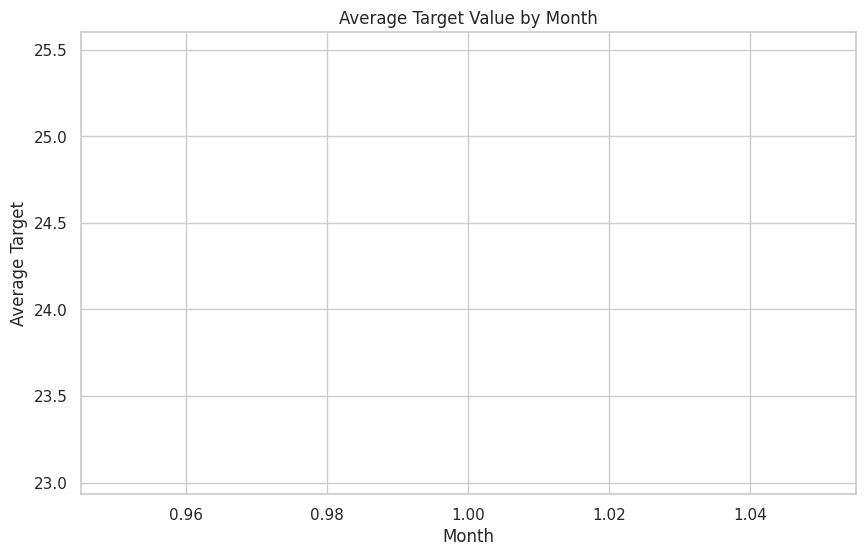

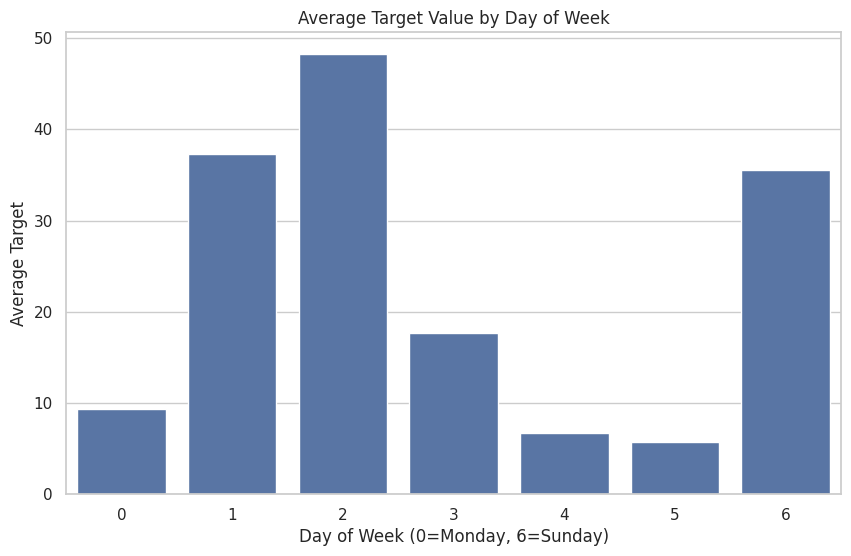

In [15]:
if 'date_column' in df.columns and pd.api.types.is_datetime64_any_dtype(df['date_column']):
    print("Performing seasonal analysis based on 'date_column':")
    df['year'] = df['date_column'].dt.year
    df['month'] = df['date_column'].dt.month
    df['day_of_week'] = df['date_column'].dt.dayofweek # Monday=0, Sunday=6

    # Example: Sales by month (assuming 'target' column exists)
    if 'target' in df.columns:
        monthly_avg = df.groupby('month')['target'].mean().reset_index()
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='month', y='target', data=monthly_avg)
        plt.title('Average Target Value by Month')
        plt.xlabel('Month')
        plt.ylabel('Average Target')
        plt.show()
    else:
        print("No 'target' column found for seasonal analysis demonstration.")

    # Example: Sales by day of week
    if 'target' in df.columns:
        daily_avg = df.groupby('day_of_week')['target'].mean().reset_index()
        plt.figure(figsize=(10, 6))
        sns.barplot(x='day_of_week', y='target', data=daily_avg)
        plt.title('Average Target Value by Day of Week')
        plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
        plt.ylabel('Average Target')
        plt.show()
    else:
        print("No 'target' column found for seasonal analysis demonstration.")

else:
    print("No 'date_column' or it's not in datetime format. Skipping seasonal analysis.")
    print("To perform seasonal analysis, ensure you have a datetime column (e.g., 'date_column') and a numerical column for analysis (e.g., 'target').")